In [2]:
import pandas as pd

orders = pd.read_csv("C:\\Users\\lenovo\\Downloads\\archive (8)\\olist_orders_dataset.csv")
customers = pd.read_csv("C:\\Users\\lenovo\\Downloads\\archive (8)\\olist_customers_dataset.csv")
order_items = pd.read_csv("C:\\Users\\lenovo\\Downloads\\archive (8)\\olist_order_items_dataset.csv")
payments = pd.read_csv("C:\\Users\\lenovo\\Downloads\\archive (8)\\olist_order_payments_dataset.csv")
products = pd.read_csv("C:\\Users\\lenovo\\Downloads\\archive (8)\\olist_products_dataset.csv")

orders.head()
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [3]:
order_items['total_price'] = order_items['price'] + order_items['freight_value']

In [4]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04


In [5]:
# Merge orders + customers
df = orders.merge(customers, on="customer_id", how="left")

# Merge with order_items
df = df.merge(order_items, on="order_id", how="left")

# Merge with payments
df = df.merge(payments, on="order_id", how="left")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_id,seller_id,shipping_limit_date,price,freight_value,total_price,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,1.0,credit_card,3.0,179.12


In [6]:
df.shape
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 176
order_delivered_carrier_date     2074
order_delivered_customer_date    3397
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     830
product_id                        830
seller_id                         830
shipping_limit_date               830
price                             830
freight_value                     830
total_price                       830
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
dtype: int64

In [7]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [8]:
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month

In [9]:
df['revenue'] = df['price'] + df['freight_value']

In [10]:
df['revenue'].sum()

np.float64(16566687.309999999)

In [11]:
monthly_sales = df.groupby(['year','month'])['revenue'].sum().reset_index()
monthly_sales

,year,month,revenue
0,2016,9,354.75
1,2016,10,58550.03
2,2016,12,19.62
3,2017,1,146455.54
4,2017,2,302230.37
5,2017,3,457782.29
6,2017,4,448742.78
7,2017,5,630089.88
8,2017,6,526495.91
9,2017,7,627312.81


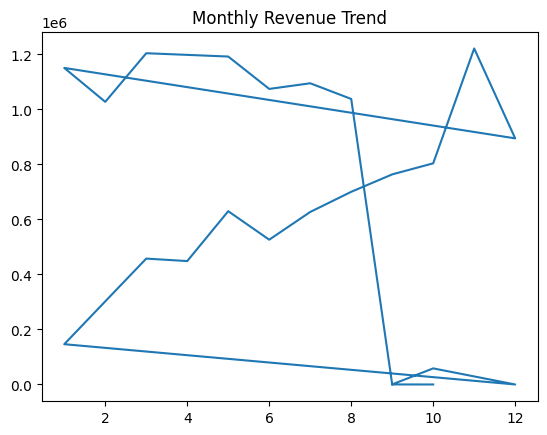

In [12]:
import matplotlib.pyplot as plt

plt.plot(monthly_sales['month'], monthly_sales['revenue'])
plt.title("Monthly Revenue Trend")
plt.show()

In [13]:
import sqlite3

conn = sqlite3.connect("ecommerce.db")

df.to_sql("ecommerce", conn, if_exists="replace", index=False)

118434

In [14]:
import pandas as pd

pd.read_sql("SELECT * FROM ecommerce LIMIT 5", conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,total_price,payment_sequential,payment_type,payment_installments,payment_value,year,month,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,38.71,1.0,credit_card,1.0,18.12,2017,10,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,38.71,3.0,voucher,1.0,2.00,2017,10,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,38.71,2.0,voucher,1.0,18.59,2017,10,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,141.46,1.0,boleto,1.0,141.46,2018,7,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,179.12,1.0,credit_card,3.0,179.12,2018,8,179.12


In [15]:
import pandas as pd

pd.read_sql("SELECT * FROM ecommerce LIMIT 5", conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,total_price,payment_sequential,payment_type,payment_installments,payment_value,year,month,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,38.71,1.0,credit_card,1.0,18.12,2017,10,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,38.71,3.0,voucher,1.0,2.00,2017,10,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,38.71,2.0,voucher,1.0,18.59,2017,10,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,141.46,1.0,boleto,1.0,141.46,2018,7,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,179.12,1.0,credit_card,3.0,179.12,2018,8,179.12


In [17]:
pd.read_sql("""
SELECT ROUND(SUM(revenue), 2) AS total_revenue
FROM ecommerce
""", conn)

,total_revenue
0,16566687.31


In [18]:
pd.read_sql("""
SELECT payment_type, ROUND(SUM(revenue), 2) AS revenue
FROM ecommerce
GROUP BY payment_type
ORDER BY revenue DESC
""", conn)

,payment_type,revenue
0,credit_card,12723914.88
1,boleto,2842240.29
2,voucher,785081.94
3,debit_card,215306.74
4,NaN,143.46
5,not_defined,NaN


In [19]:
pd.read_sql("""
SELECT customer_unique_id, ROUND(SUM(revenue), 2) AS total_spent
FROM ecommerce
GROUP BY customer_unique_id
ORDER BY total_spent DESC
LIMIT 5
""", conn)

,customer_unique_id,total_spent
0,0a0a92112bd4c708ca5fde585afaa872,13664.08
1,8af7ac63b2efbcbd88e5b11505e8098a,13281.71
2,c4b224d2c784bae11ae98b6ae9f2454c,11111.40
3,85963fd37bfd387aa6d915d8a1065486,10553.28
4,be74c431147c32ab2d7c7cef5e4a995f,10055.22


In [20]:
pd.read_sql("""
SELECT customer_unique_id, COUNT(order_id) AS orders
FROM ecommerce
GROUP BY customer_unique_id
HAVING COUNT(order_id) > 1
""", conn)

,customer_unique_id,orders
0,00053a61a98854899e70ed204dd4bafe,2
1,000de6019bb59f34c099a907c151d855,2
2,000e309254ab1fc5ba99dd469d36bdb4,2
3,000fbf0473c10fc1ab6f8d2d286ce20c,4
4,001147e649a7b1afd577e873841632dd,2
...,...,...
14420,ffeddf8aa7cdecf403e77b2e9a99e2ea,2
14421,fff22793223fe80c97a8fd02ac5c6295,3
14422,fff5eb4918b2bf4b2da476788d42051c,6
14423,fff7219c86179ca6441b8f37823ba3d3,2


In [21]:
df.to_csv("final_dataset.csv", index=False)